In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning imports
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#insta users dataset below:

In [83]:
df = pd.read_csv("C:/dev/ipynb_pdf/Instagram visits clustering.csv", encoding='utf-8-sig', low_memory=False)
df.head(5)

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [84]:
print(df.columns.tolist())

['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)']


In [85]:
df.columns = ['id', 'visits', 'rank']
df.head(n=5)

,id,visits,rank
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [86]:
df = df.drop(columns=['id'])
df.head(5)

,visits,rank
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


In [87]:
# 2. Isolate the features we want to cluster (Income and Score)
X = df[['visits', 'rank']]

In [88]:
# 3. Scale the data (Crucial for distance-based algorithms!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. The Elbow Method Loop
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

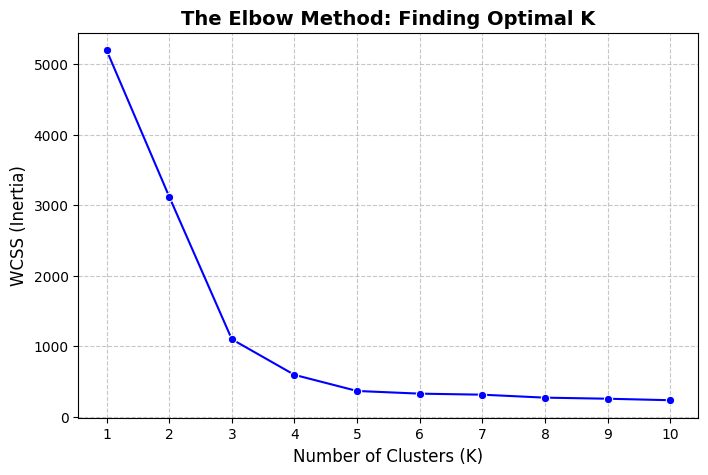

In [89]:
# 5. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='b')
plt.title('The Elbow Method: Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

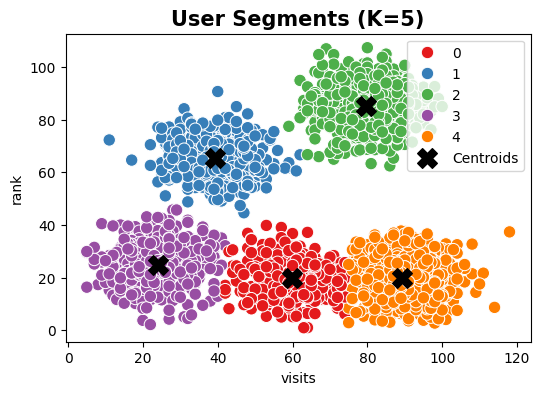

In [90]:
# 1. Build the final model with our optimal K
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
kmeans.fit(X_scaled)

# 2. Add the cluster labels back to our dataframe so we can color-code the plot
df['cluster'] = kmeans.labels_

# 3. Plot the final result
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['visits'], y=df['rank'], hue=df['cluster'], palette="Set1", s=80)

# (Optional: If we want to plot the centers, we have to "unscale" them first so they match the plot's axes)
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_unscaled[:, 0], centers_unscaled[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.title('User Segments (K=5)', fontsize=15, fontweight='bold')
plt.legend()
plt.show()

credit card usage dataset below:

In [106]:
df = pd.read_csv("C:/dev/ipynb_pdf/cc_card.csv", encoding='utf-8-sig', low_memory=False)
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [107]:
print(df.columns.tolist())

['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [108]:
df = df.drop('CUST_ID', axis=1)

In [109]:
# 2. Handle missing values (Fill blanks with the median of that column)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [110]:
# 3. Scale the data
# 'BALANCE' could be $5,000, but 'PURCHASES_FREQUENCY' is between 0.0 and 1.0. 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [111]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

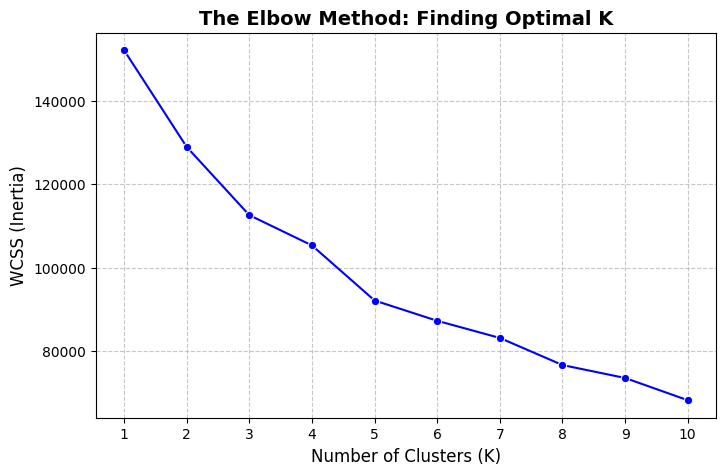

In [112]:
# 5. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='b')
plt.title('The Elbow Method: Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

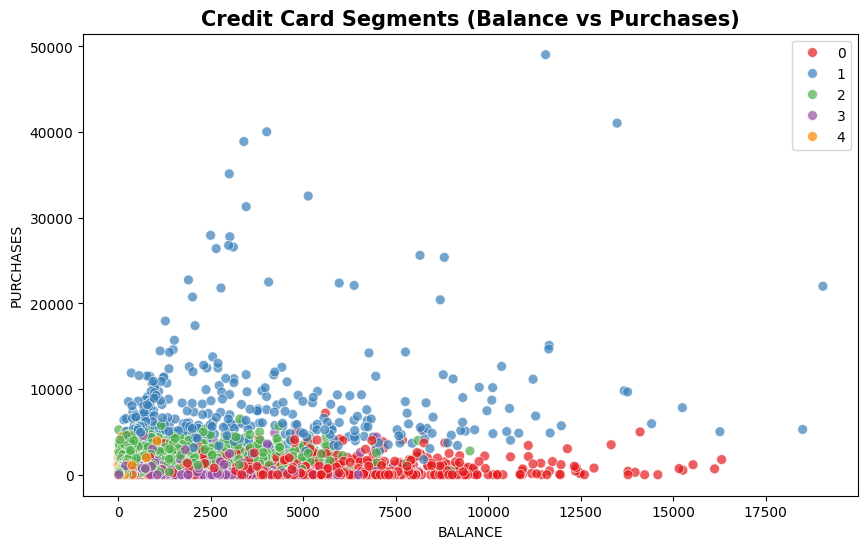

In [113]:
# 1. Build the final model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
kmeans.fit(X_scaled)

# Add the cluster labels back to our dataframe
df['cluster'] = kmeans.labels_

# 2. Plot the final result using just two specific columns
plt.figure(figsize=(10, 6))
# Replacing 'visits' and 'rank' with 'BALANCE' and 'PURCHASES'
sns.scatterplot(x=df['BALANCE'], y=df['PURCHASES'], hue=df['cluster'], palette="Set1", s=50, alpha=0.7)

plt.title('Credit Card Segments (Balance vs Purchases)', fontsize=15, fontweight='bold')
plt.legend()
plt.show()

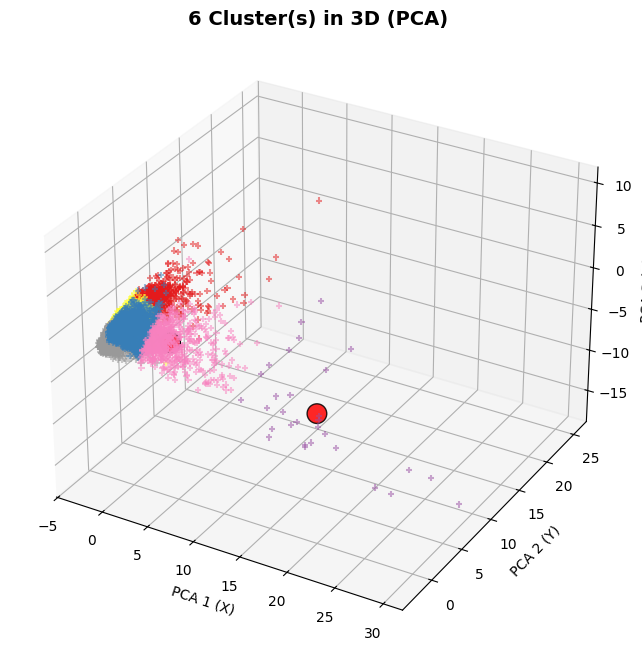

In [114]:
from sklearn.decomposition import PCA
# Matplotlib handles 3D natively now when you specify projection='3d'

# 1. Use PCA to compress the 17 features into 3 "Super Features" (X, Y, Z)
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

# 2. Put it into a dataframe named df3d so it matches your code exactly
df3d = pd.DataFrame(X_pca_3d, columns=['X', 'Y', 'Z'])

# 3. Your modified plotting function
def plot_result_3d(kmeans):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the data points (using cmap='Set1' to automatically color the labels)
    ax.scatter3D(df3d['X'], df3d['Y'], df3d['Z'], c=kmeans.labels_, cmap='Set1', marker='+', alpha=0.5)
    
    # Plot the cluster centers (Centroids)
    ax.scatter3D(kmeans.cluster_centers_[:,0], 
                 kmeans.cluster_centers_[:,1], 
                 kmeans.cluster_centers_[:,2], 
                 c='red', s=200, marker='o', edgecolor='black')
    
    ax.set_title(str(kmeans.n_clusters) + ' Cluster(s) in 3D (PCA)', fontsize=14, fontweight='bold')
    
    # Labeling the new axes
    ax.set_xlabel('PCA 1 (X)')
    ax.set_ylabel('PCA 2 (Y)')
    ax.set_zlabel('PCA 3 (Z)')
    
    plt.show()

# 4. Build a KMeans model for our chosen K (Let's stick with 6 based on the elbow)
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init='auto')
kmeans.fit(df3d)

# 5. Call your plot function!
plot_result_3d(kmeans)